In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')
import numpy.fft as fft
mc = 'mediumorchid'

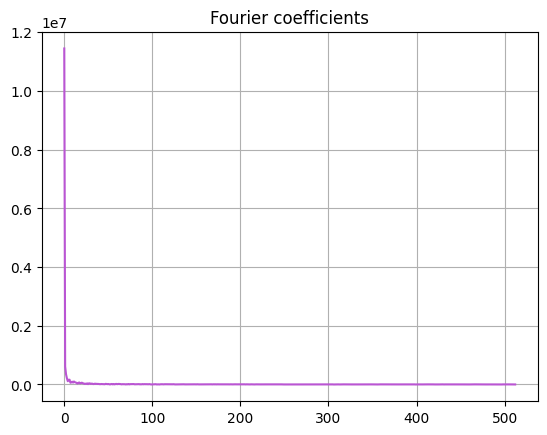

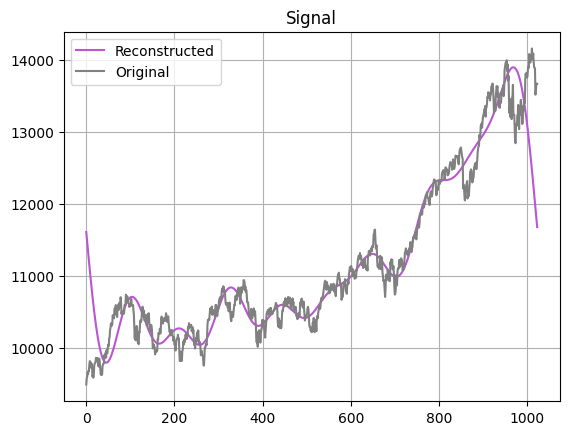

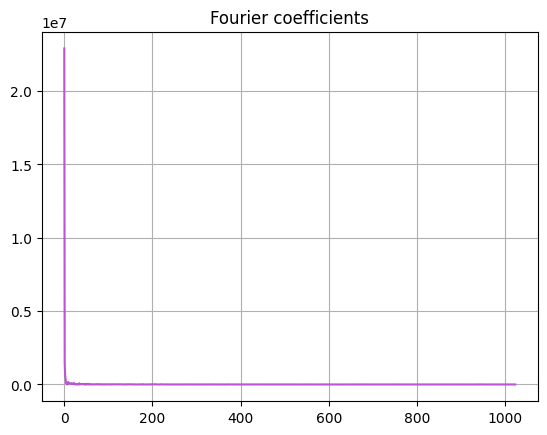

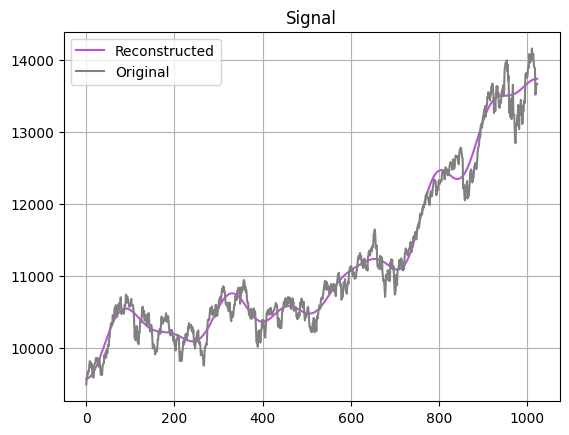

In [ ]:
def fct(y):
    N = len(y)
    y2 = np.zeros(2 * N, float)

    for n in range(N):
        y2[n] = y[n] 
        y2[2 * N - 1 - n] = y[n]
    c = fft.rfft(y2)

    phi = np.exp(-1j * np.pi * np.arange(N) / (2 * N))
    return np.real(phi * c[:N])

def ifct(a):
    N = len(a)
    c = np.zeros(N, complex)
    phi = np.exp(1j * np.pi * np.arange(N) / (2 * N))
    c[:N] = phi * a

    return fft.irfft(c)[:N]


dow2 = np.loadtxt("dow2.txt")
c = fft.rfft(dow2)

plt.plot(abs(c), color=mc)
plt.title('Fourier coefficients')
plt.grid()
plt.show()

c[int(0.02*len(c)):] = 0
r = fft.irfft(c)

plt.plot(r, color=mc, label = 'Reconstructed')
plt.plot(dow2, color='gray', label = 'Original')
plt.title('Signal')

plt.legend()
plt.grid()
plt.show()

c = fct(dow2)

plt.plot(abs(c), color=mc)
plt.title('Fourier coefficients')
plt.grid()
plt.show()

c[int(0.02*len(c)):] = 0
r = ifct(c)

plt.plot(r, color=mc, label = 'Reconstructed')
plt.plot(dow2, color='gray', label = 'Original')
plt.title('Signal')
plt.legend()
plt.grid()
plt.show()